In [15]:
import pandas as pd
from os import makedirs
from pathlib import Path

from hydra.core.analysis.utils import comparison_discovery

In [16]:
root_dir = "../../"

In [17]:
makedirs(f"{root_dir}figures/", exist_ok=True)

In [18]:
results = [results for path, results in comparison_discovery(f"{root_dir}samples")]
df = pd.DataFrame(results)

## Communities

In [19]:
df_t = df[['name', 'dataset_name', 'kind', 'normalized_mutual_information', 'clique_expansion_modularity', 'hypergraph_modularity', 'bipartite_graph_modularity']]
df_t['name'] = df_t['name'].apply(lambda x: x[0])
df_t['kind'] = df_t['kind'].apply(lambda x: x[0])
df_agg = df_t.groupby(['dataset_name', 'name', 'kind']).mean().reset_index()

metric_cols = [c for c in df_agg.columns if c not in ("dataset_name", "name", "kind")]

df_ranked = df_agg.copy()
df_ranked['normalized_mutual_information'] = -df_ranked['normalized_mutual_information']  # Invert NMI for ranking (higher is better)

# 1) Rank each metric within the same dataset_name (1 = best). Change ascending=True if "lower is better".
for c in metric_cols:
    df_ranked[f"{c}_rank"] = (
        df_ranked.groupby(["dataset_name", "kind"])[c]
        .rank(method="average", ascending=True)
    )

rank_cols = [f"{c}_rank" for c in metric_cols]

# 2) Average rank per row (within its dataset_name)
df_ranked["avg_rank"] = df_ranked[rank_cols].mean(axis=1)

df_ranked['normalized_mutual_information'] = -df_ranked['normalized_mutual_information']

# 4) Drop column-specific rank columns
df_final = (
    df_ranked.drop(columns=rank_cols)
    .sort_values(["dataset_name", "kind", "avg_rank", "name"])
    .reset_index(drop=True)
)

df_latex = (
    df_final
    .set_index(["dataset_name", "kind"])   # hierarchical indices on rows
    .sort_index()
)

# ------------------------------
# MAKE LATEX TABLE
# ------------------------------

def _latex_escape(s: str) -> str:
    # minimal escaping for group labels used inside \multicolumn{...}{...}{...}
    return (str(s)
            .replace("\\", r"\textbackslash{}")
            .replace("&", r"\&")
            .replace("%", r"\%")
            .replace("$", r"\$")
            .replace("#", r"\#")
            .replace("_", r"\_")
            .replace("{", r"\{")
            .replace("}", r"\}")
            .replace("~", r"\textasciitilde{}")
            .replace("^", r"\textasciicircum{}"))

# Columns that will actually appear in the table (dataset/kind become group headers)
data_cols = [c for c in df_final.columns if c not in ("dataset_name", "kind")]
ncols = len(data_cols)

# Build LaTeX manually, but reuse pandas to render the body rows safely
# pick one: r"\small", r"\footnotesize", r"\scriptsize", r"\tiny"
font_cmd = r"\footnotesize"

lines = []
col_format = "l" + "r" * (ncols - 1)  # first col left, the rest right; adjust if you prefer

lines.append(r"\begingroup")
lines.append(font_cmd)

lines.append(r"\begin{tabular}{" + col_format + r"}")
lines.append(r"\toprule")
lines.append(" & ".join(_latex_escape(c) for c in data_cols) + r" \\")
lines.append(r"\midrule")

for dataset_name, ds_df in df_final.groupby("dataset_name", sort=False):
    lines.append("\\midrule")
    lines.append(
        rf"\multicolumn{{{ncols}}}{{c}}{{\textbf{{{_latex_escape(dataset_name)}}}}} \\"
    )
    lines.append("\\midrule")

    for kind, k_df in ds_df.groupby("kind", sort=False):
        lines.append("\\midrule")
        lines.append(
            rf"\multicolumn{{{ncols}}}{{c}}{{\emph{{{_latex_escape(kind)}}}}} \\"
        )
        lines.append("\\midrule")

        body = k_df[data_cols].to_latex(
            index=False,
            header=False,
            escape=True,     # escapes data cells
        ).splitlines()

        # keep only the actual row lines from pandas' mini-table
        body = [
            ln for ln in body
            if not ln.startswith(r"\begin{tabular}")
            and not ln.startswith(r"\toprule")
            and not ln.startswith(r"\midrule")
            and not ln.startswith(r"\bottomrule")
            and not ln.startswith(r"\end{tabular}")
        ]
        lines.extend(body)

    lines.append(r"\midrule")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")

lines.append(r"\endgroup")

makedirs(f"{root_dir}tables/", exist_ok=True)
Path(f"{root_dir}tables/communities.tex").write_text("\n".join(lines), encoding="utf-8")

df_final

,dataset_name,name,kind,normalized_mutual_information,clique_expansion_modularity,hypergraph_modularity,bipartite_graph_modularity,avg_rank
0,daqh/NDC-classes,BVAE-HyDRA-S,conditional,0.740639,0.002753,0.002716,0.002669,1.00
1,daqh/NDC-classes,HyperPLR,conditional,0.670477,0.012816,0.019814,0.012096,2.00
2,daqh/NDC-classes,TheRA,unconditional,0.715949,0.093795,0.188128,0.151561,1.75
3,daqh/NDC-classes,Hyperlap+,unconditional,0.593429,0.182125,0.118730,0.094235,2.25
4,daqh/NDC-classes,HyperDK00,unconditional,0.696758,0.381836,0.381264,0.339399,3.50
5,daqh/NDC-classes,Hyperlap,unconditional,0.519281,0.157138,0.149667,0.163204,3.75
6,daqh/NDC-classes,HyperDK11,unconditional,0.664890,0.425211,0.415079,0.343922,4.75
7,daqh/NDC-classes,SubsetSampling,unconditional,0.537787,0.447157,0.406200,0.355291,5.50
8,daqh/NDC-classes,HyperPA,unconditional,0.519806,0.477718,0.504453,0.470122,7.25
9,daqh/NDC-classes,NaivePA,unconditional,0.533889,0.504659,0.537010,0.469053,7.25


## Higher-order dissimilarity measures for hypergraph comparison

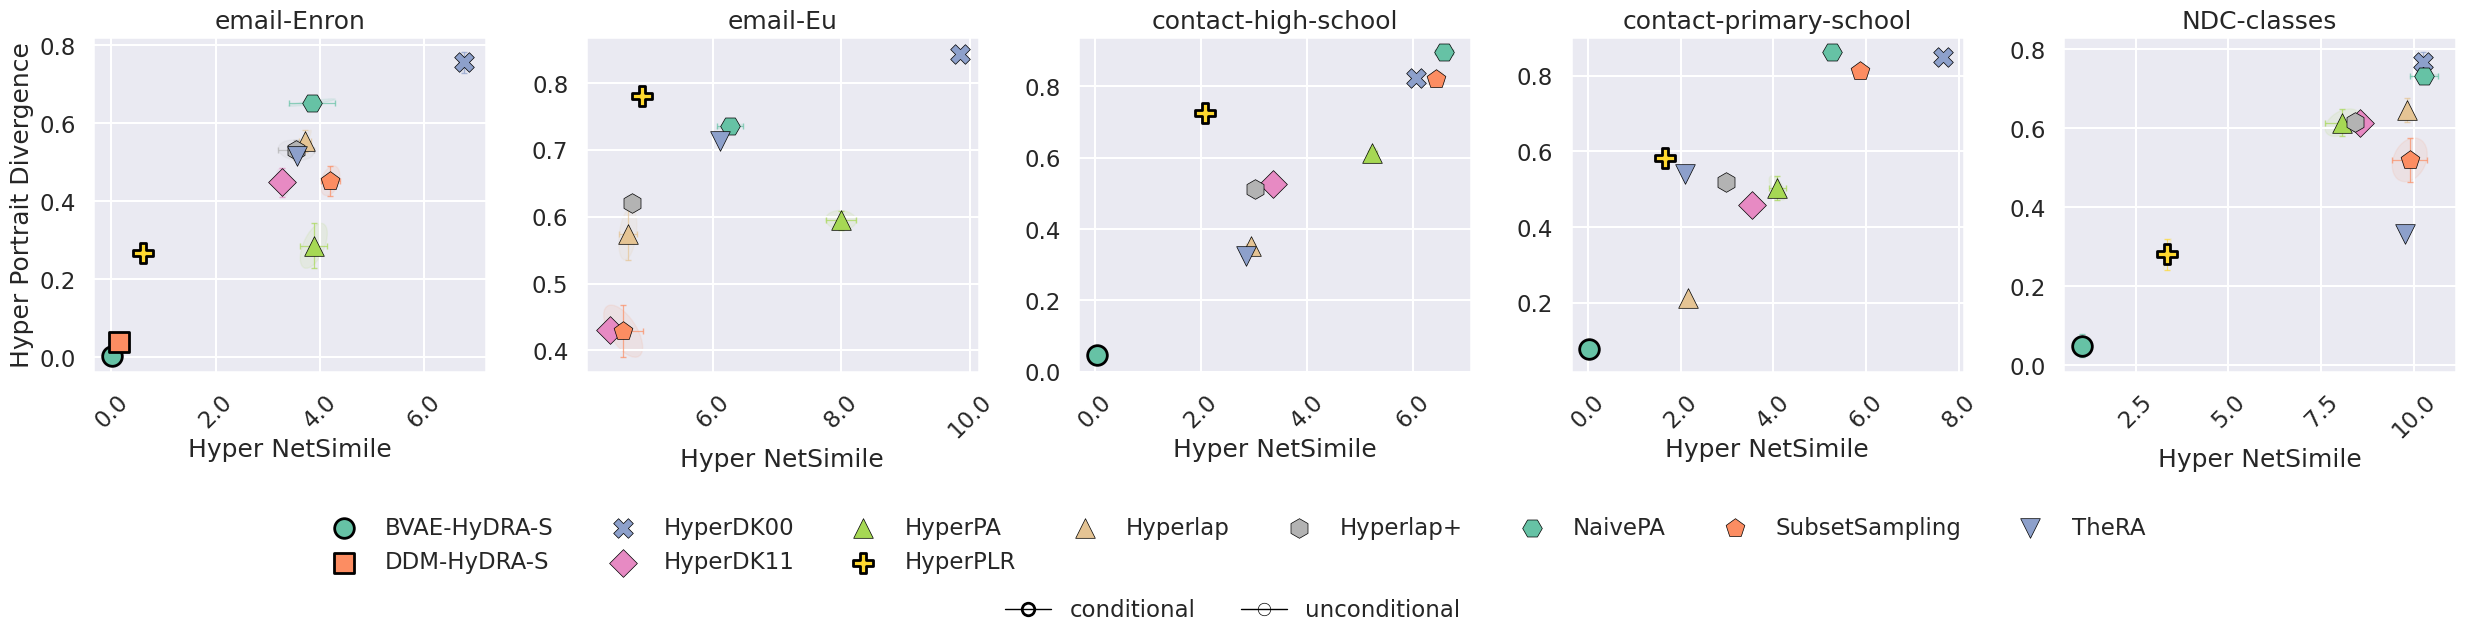

In [20]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

df_dissimilarity = df.copy()

df_dissimilarity['kind'] = df_dissimilarity['kind'].apply(lambda x: x[0])

def covariance_ellipse(
    ax, x, y, *, n_std=1.0, edgecolor="k", facecolor="none",
    alpha=0.12, lw=1.0, zorder=0
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 3:
        return
    cov = np.cov(x, y)
    if not np.all(np.isfinite(cov)):
        return

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0))
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ell = Ellipse(
        (x.mean(), y.mean()),
        width, height,
        angle=angle,
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        lw=lw,
        label="_nolegend_",
        zorder=zorder,
    )
    ax.add_patch(ell)

# ADD (anywhere above the plotting loop)
def _kind_proxy_handle(edgecolor, linewidth, linestyle):
    return Line2D(
        [0], [0],
        marker="o",
        linestyle=linestyle,
        color=edgecolor,
        markerfacecolor="none",
        markeredgecolor=edgecolor,
        markeredgewidth=linewidth,
        linewidth=1.0,
    )

# =========================
# Kind -> marker-edge config
# =========================
KIND_EDGE_CONFIGS = [
    {"kinds": ["conditional"], "label": "conditional", "edgecolor": "black", "linewidth": 2.0, "linestyle": "solid"},
    {"kinds": ["unconditional"], "label": "unconditional", "edgecolor": "black", "linewidth": 0.5, "linestyle": "solid"},
]

def kind_edge_style(kind):
    for cfg in KIND_EDGE_CONFIGS:
        kinds = cfg.get("kinds", [])
        if isinstance(kinds, str):
            kinds = [kinds]
        if kind in kinds:
            return {k: v for k, v in cfg.items() if k != "kinds"}
    raise ValueError(f"Kind '{kind}' not found in any KIND_EDGE_CONFIGS entry")

unique_datasets = df_dissimilarity["dataset_name"].unique()

# --- available datasets in the data (keeps first-seen order) ---
available_datasets = list(df_dissimilarity["dataset_name"].unique())

# --- YOUR desired order (use the exact strings found in dataset_name) ---
DATASET_ORDER = [
    "daqh/email-Enron",
    "daqh/email-Eu",
    "daqh/contact-high-school",
    "daqh/contact-primary-school",
    "daqh/NDC-classes"
]

def ordered_datasets(available, order=None, *, strict=True):
    if not order:
        return available
    missing = [d for d in order if d not in available]
    if missing and strict:
        raise ValueError(f"DATASET_ORDER contains unknown dataset_name(s): {missing}")
    ordered = [d for d in order if d in available]
    remainder = [d for d in available if d not in ordered]
    return ordered + remainder

unique_datasets = ordered_datasets(available_datasets, DATASET_ORDER, strict=True)

# --- consistent names across all subplots ---
tmp_names = df_dissimilarity["name"].apply(lambda x: x[0])
all_names = sorted(tmp_names.unique())

# --- markers (one per name) ---
marker_list = ["o", "s", "X", "D", "^", "P", "^", "h", "H", "p", "v", "8", ">", "*"]
marker_cycle = itertools.cycle(marker_list)
marker_map = {n: next(marker_cycle) for n in all_names}

# --- colors (one per name, fixed across all subplots) ---
palette = sns.color_palette("Set2", n_colors=len(all_names))
color_map = dict(zip(all_names, palette))

sns.set_theme(style="darkgrid", context="talk")

fig, ax = plt.subplots(
    ncols=len(unique_datasets),
    figsize=(5 * len(unique_datasets), 6),
)
if len(unique_datasets) == 1:
    ax = [ax]

# for the global legend (use actual plotted artists)
name_handles = {}

for i, dataset_name in enumerate(unique_datasets):
    df_dissimilarity_raw = df_dissimilarity[df_dissimilarity["dataset_name"] == dataset_name][
        ["name", "kind", "hyper_net_simile", "hyper_portrait_divergence"]
    ].copy()
    df_dissimilarity_raw["name"] = df_dissimilarity_raw["name"].apply(lambda x: x[0])

    # per-name stats + kind (mode; falls back to first)
    df_dissimilarity_stats = (
        df_dissimilarity_raw.groupby("name", as_index=False)
        .agg(
            kind=("kind", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
            x_mean=("hyper_net_simile", "mean"),
            x_std=("hyper_net_simile", "std"),
            y_mean=("hyper_portrait_divergence", "mean"),
            y_std=("hyper_portrait_divergence", "std"),
        )
    )

    # plot points manually so marker edge can vary per-point (by kind)
    for _, r in df_dissimilarity_stats.iterrows():
        n = r["name"]
        c = color_map[n]
        m = marker_map[n]
        es = kind_edge_style(r["kind"])

        sc = ax[i].scatter(
            r["x_mean"], r["y_mean"],
            s=200,
            marker=m,
            c=[c],
            edgecolors=es["edgecolor"],
            linewidths=es["linewidth"],
            linestyles=es["linestyle"],
            zorder=2,
            label="_nolegend_",
        )
        if i == 0 and n not in name_handles:
            name_handles[n] = sc

        # errorbars (mean ± 1 std), keep same color as marker fill
        if np.isfinite(r["x_std"]) and np.isfinite(r["y_std"]):
            ax[i].errorbar(
                r["x_mean"], r["y_mean"],
                xerr=r["x_std"], yerr=r["y_std"],
                fmt="none",
                ecolor=c,
                elinewidth=0.9,
                capsize=2,
                alpha=0.7,
                zorder=1,
                label="_nolegend_",
            )

        # covariance ellipse (1-sigma), keep ellipse colored by marker fill
        sub = df_dissimilarity_raw[df_dissimilarity_raw["name"] == n]
        covariance_ellipse(
            ax[i],
            sub["hyper_net_simile"],
            sub["hyper_portrait_divergence"],
            n_std=1.0,
            edgecolor=c,
            facecolor=c,
            alpha=0.10,
            lw=1.0,
            zorder=0,
        )

    ax[i].set_title(dataset_name.split("/")[-1])
    ax[i].set_xlabel("Hyper NetSimile")
    if i == 0:
        ax[i].set_ylabel("Hyper Portrait Divergence")
    else:
        ax[i].set_ylabel("")

    ax[i].tick_params(axis="x", rotation=45)
    ax[i].xaxis.set_major_formatter(plt.FormatStrFormatter("%.1f"))
    ax[i].yaxis.set_major_formatter(plt.FormatStrFormatter("%.1f"))

# bottom-center legend for names (marker+color; edge reflects that name's kind if consistent)
handles = [name_handles[n] for n in all_names if n in name_handles]
labels = [n for n in all_names if n in name_handles]

# --- name legend (existing) ---
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=int(len(labels) / 1.3),
    frameon=False,
)

# --- kind legend (NEW, placed under the name legend) ---
kind_handles = []
kind_labels = []
for cfg in KIND_EDGE_CONFIGS:
    kind_handles.append(_kind_proxy_handle(cfg["edgecolor"], cfg["linewidth"], cfg["linestyle"]))
    kind_labels.append(cfg.get("label", ",".join(cfg.get("kinds", []))))

# (optional) include a default/other entry
fig.legend(
    kind_handles,
    kind_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(kind_labels),
    frameon=False,
)

# and give a bit more bottom room
fig.tight_layout()
fig.subplots_adjust(bottom=0.35)

# Save the figure as pdf
fig.savefig(f"{root_dir}figures/dissimilarity_scatter.pdf", format="pdf", bbox_inches="tight")